In [1]:
import torch, sys
print("Python:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch:", torch.__version__, "| CUDA runtime:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: C:\Users\HP\anaconda3\envs\gnncuda\python.exe
CUDA available: True
PyTorch: 2.8.0+cu128 | CUDA runtime: 12.8
GPU: NVIDIA RTX A4500


In [2]:
import torch, sys
print("Python:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch:", torch.__version__, "| CUDA runtime:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: C:\Users\HP\anaconda3\envs\gnncuda\python.exe
CUDA available: True
PyTorch: 2.8.0+cu128 | CUDA runtime: 12.8
GPU: NVIDIA RTX A4500


In [3]:
# --- GPU / CUDA setup (auto-detects RTX A4500 and uses it if available) ---
import torch, os

print("CUDA available:", torch.cuda.is_available())
print("PyTorch:", torch.__version__, " | CUDA runtime:", torch.version.cuda)
if torch.cuda.is_available():
    try:
        print("GPU:", torch.cuda.get_device_name(0))
    except Exception as e:
        print("GPU name query failed:", e)

# unified device handle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Optional: speed-up for fixed input sizes (turn off if you need exact determinism)
try:
    torch.backends.cudnn.benchmark = True
except Exception:
    pass

# Helper: safe torch.load that always maps to the chosen device
def load_state_dict_safe(path, device=device):
    sd = torch.load(path, map_location=device)
    if isinstance(sd, dict) and 'state_dict' in sd:
        sd = sd['state_dict']
    # Strip 'module.' prefix if saved with DataParallel/DDP
    from collections import OrderedDict
    sd = OrderedDict((k.replace('module.', ''), v) for k, v in sd.items())
    return sd

print("Using device ->", device)


CUDA available: True
PyTorch: 2.8.0+cu128  | CUDA runtime: 12.8
GPU: NVIDIA RTX A4500
Using device -> cuda


# SETUP

In [5]:
!pwd

'pwd'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.


In [6]:
!pip install gdown

In [7]:
!gdown 1avwAoXXwlnhsjtJo5Ux9vO1xPQVJJW3M

Downloading...
From (original): https://drive.google.com/uc?id=1avwAoXXwlnhsjtJo5Ux9vO1xPQVJJW3M
From (redirected): https://drive.google.com/uc?id=1avwAoXXwlnhsjtJo5Ux9vO1xPQVJJW3M&confirm=t&uuid=118def17-9d86-47de-8731-362f37d8f262
To: C:\Users\HP\Downloads\GNNRL_v2\GNNRL_v2.zip

  0%|          | 0.00/4.36G [00:00<?, ?B/s]
  0%|          | 524k/4.36G [00:00<30:00, 2.42MB/s]
  0%|          | 1.05M/4.36G [00:00<21:12, 3.42MB/s]
  0%|          | 3.67M/4.36G [00:00<06:31, 11.1MB/s]
  0%|          | 6.82M/4.36G [00:00<04:21, 16.7MB/s]
  0%|          | 14.2M/4.36G [00:00<02:08, 33.8MB/s]
  0%|          | 20.4M/4.36G [00:00<01:44, 41.4MB/s]
  1%|          | 25.2M/4.36G [00:00<01:47, 40.4MB/s]
  1%|          | 31.5M/4.36G [00:00<01:33, 46.2MB/s]
  1%|          | 36.7M/4.36G [00:01<01:50, 39.1MB/s]
  1%|          | 41.4M/4.36G [00:01<01:47, 40.2MB/s]
  1%|1         | 47.7M/4.36G [00:01<01:34, 45.4MB/s]
  1%|1         | 53.0M/4.36G [00:01<01:41, 42.4MB/s]
  1%|1         | 58.7M/4.36G [00:01<01:

In [8]:
!unzip GNNRL_v2.zip

'unzip'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.


In [9]:
!pip install -r requirements.txt

In [10]:
import glob
import os
import torch
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# PYTHONPATH 경로 설정
import sys
sys.path.append("src/gnn/")

from src.gnn.scaler.feature_scaler import GraphTargetScaler
import src.gnn.utils.pyg_dataset as pyg_dataset
from src.gnn.utils.utils import train_valid_test_split_indices


# constant
EPW_FILE_PATH = "./src/gnn/EPW_Mar-Nov_SolarData_WithTemp_v2.csv"
SUN_NODE_ID = 0
PITCH_NODE_ID = 1
START_NODE_ID = 2
END_NODE_ID = 1850
folder_path = "./src/gnn/data"


In [11]:
node_csv_files = glob.glob(os.path.join(folder_path, "**", "*node*.csv"), recursive=True)
edge_csv_files = glob.glob(os.path.join(folder_path, "**", "*edge*.csv"), recursive=True)
node_csv_files.sort()
edge_csv_files.sort()

# File Sanity Check
for node_file in node_csv_files[:]:
    expected_edge_file = node_file.replace('node', 'edge')

    if expected_edge_file not in edge_csv_files:
        print(f"[Warning] Corresponding edge file not found for: {node_file}")
        print(f"          '{node_file}' will be removed from the node list.")
        node_csv_files.remove(node_file)

for edge_file in edge_csv_files[:]:
    expected_node_file = edge_file.replace('edge', 'node')
    if expected_node_file not in node_csv_files:
        print(f"[Warning] Corresponding node file not found for: {edge_file}")
        print(f"          '{edge_file}' will be removed from the edge list.")

        # edge_csv_files 리스트에서 해당 파일을 제거합니다.
        edge_csv_files.remove(edge_file)


print("\n--- Sanity Check Complete ---")
print("Updated node_csv_files:", len(node_csv_files))
print("Updated edge_csv_files:", len(edge_csv_files))

[Warning] Corresponding edge file not found for: ./src/gnn/data\0_close_0to90\0_close_0to90_Output_1374-42-86-0.65-10-25-18_case1374_node.csv
          './src/gnn/data\0_close_0to90\0_close_0to90_Output_1374-42-86-0.65-10-25-18_case1374_node.csv' will be removed from the node list.

--- Sanity Check Complete ---
Updated node_csv_files: 9378
Updated edge_csv_files: 9378


In [12]:

train_idx, valid_idx, test_idx = train_valid_test_split_indices(
    n_samples=len(node_csv_files),
    train_size=0.7,
    valid_size=0.15,
    test_size=0.15,
    random_state=42,
)

train_node_csv_files = [node_csv_files[i] for i in train_idx]
train_edge_csv_files = [edge_csv_files[i] for i in train_idx]

valid_node_csv_files = [node_csv_files[i] for i in valid_idx]
valid_edge_csv_files = [edge_csv_files[i] for i in valid_idx]

test_node_csv_files = [node_csv_files[i] for i in test_idx]
test_edge_csv_files = [edge_csv_files[i] for i in test_idx]

INFO:src.gnn.utils.utils:train_size: 0.7, valid_size: 0.15, test_size: 0.15
INFO:src.gnn.utils.utils:train_idx: 6564, valid_idx: 1407, test_idx: 1407


In [13]:
train_datapyg_dataset, train_fail_file_paths, _ = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=train_node_csv_files,
    edge_file_paths=train_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True,
    target_scaler=None,
)


valid_datapyg_dataset, valid_fail_file_paths, _ = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=valid_node_csv_files,
    edge_file_paths=valid_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True,
    target_scaler=None,
)

test_datapyg_dataset, test_fail_file_paths, _ = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=test_node_csv_files,
    edge_file_paths=test_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True,
    target_scaler=None,
)

print(f"Train fail file paths: {len(train_fail_file_paths)}")
print(f"Valid fail file paths: {len(valid_fail_file_paths)}")
print(f"Test fail file paths: {len(test_fail_file_paths)}")

print(len(train_datapyg_dataset))
print(len(valid_datapyg_dataset))
print(len(test_datapyg_dataset))


torch.save(train_datapyg_dataset, folder_path + '/train_datapyg_dataset.pt' )
torch.save(valid_datapyg_dataset, folder_path + '/valid_datapyg_dataset.pt' )
torch.save(test_datapyg_dataset, folder_path + '/test_datapyg_dataset.pt' )

print("Saved datasets.")


  0%|          | 0/6564 [00:00<?, ?it/s]

INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\5_close_all_45\5_close_all_45_Output_1550-42-86-0.65-11-25-18_case1550_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\4_close_all_0\4_close_all_0_Output_1528-42-86-0.65-11-21-18_case1528_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\4_close_all_0\4_close_all_0_Output_1330-42-86-0.65-10-17-18_case1330_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\2_close_45to90\2_close_45to90_Output_1407-42-86-0.65-10-31-18_case1407_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\0_close_0to90\0_close_0to90_Output_1528-42-86-0.65-11-21-18_case1528_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\4_close_all_0\4_close_all_0_Output_1484-42-86-0.65-11-13-18_case1484_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\1_open_90to0\1_open_90to0_Output_1517-42-86-0.65-11-19-18_case1517_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./s

  0%|          | 0/1407 [00:00<?, ?it/s]

INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\4_close_all_0\4_close_all_0_Output_1495-42-86-0.65-11-15-18_case1495_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\3_open_90to45\3_open_90to45_Output_1517-42-86-0.65-11-19-18_case1517_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\0_close_0to90\0_close_0to90_Output_1484-42-86-0.65-11-13-18_case1484_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\0_close_0to90\0_close_0to90_Output_1451-42-86-0.65-11-7-18_case1451_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\1_open_90to0\1_open_90to0_Output_1352-42-86-0.65-10-21-18_case1352_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\3_open_90to45\3_open_90to45_Output_1341-42-86-0.65-10-19-18_case1341_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\3_open_90to45\3_open_90to45_Output_1440-42-86-0.65-11-5-18_case1440_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn

  0%|          | 0/1407 [00:00<?, ?it/s]

INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\4_close_all_0\4_close_all_0_Output_1363-42-86-0.65-10-23-18_case1363_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\2_close_45to90\2_close_45to90_Output_1561-42-86-0.65-11-27-18_case1561_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\4_close_all_0\4_close_all_0_Output_1539-42-86-0.65-11-23-18_case1539_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\0_close_0to90\0_close_0to90_Output_1473-42-86-0.65-11-11-18_case1473_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\4_close_all_0\4_close_all_0_Output_1385-42-86-0.65-10-27-18_case1385_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\2_close_45to90\2_close_45to90_Output_1462-42-86-0.65-11-9-18_case1462_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./src/gnn/data\0_close_0to90\0_close_0to90_Output_1330-42-86-0.65-10-17-18_case1330_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./

Train fail file paths: 106
Valid fail file paths: 20
Test fail file paths: 23
6458
1387
1384
Saved datasets.


# GNN Training

In [15]:
import os
import torch
import sys
import yaml
import pandas as pd
from datetime import datetime
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'

# Add the project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Now use absolute imports
from src.gnn.utils.config_utils import load_config
from src.gnn.train.trainer import Trainer
from src.gnn.factory.model_factory import ModelFactory

# constant
BATCH_SIZE = 16
EPOCHS = 500
EARLY_STOPPING_PATIENCE = 10

In [16]:
from torch_geometric.loader import DataLoader
import torch

# Just add this right below the current device configuration code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ✅ Generate a generator tailored to the current device
generator = torch.Generator(device=device)

# Load Dataset
train_dataset = torch.load(folder_path + '/train_datapyg_dataset.pt', weights_only=False, map_location=device)
valid_dataset = torch.load(folder_path + '/valid_datapyg_dataset.pt', weights_only=False, map_location=device)
test_dataset = torch.load(folder_path + '/test_datapyg_dataset.pt', weights_only=False, map_location=device)

# ✅ Add a generator argument to DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=generator
)


INFO:src.gnn.utils.config_utils:CONFIG_DIR: C:\Users\HP\Downloads\GNNRL_v2\src\gnn\utils\..\config
INFO:src.gnn.utils.config_utils:Loading config: model gin_3_new_5
INFO:src.gnn.factory.model_factory:Model config: {'model_type': 'gin', 'description': 'Graph Isomorphism Network - A Graph Isomorphism Network model that uses node features to learn graph structure. Uses a lightweight MLP inside GIN to learn node representations.', 'model_config': {'in_channels': 4, 'hidden_channels': 512, 'global_dim': 7, 'out_dim': 1, 'num_layers': 3, 'use_edge_attr': False, 'use_global_features': True, 'coord_embed_method': 'sinusoidal', 'pooling_method': 'add', 'activation_function': 'gelu', 'dropout': 0.0, 'edge_dim': 2, 'edge_embedding_dim': 8, 'user_global_coord_embedder': False, 'special_config': {'eps': 0.0, 'train_eps': True}}}
INFO:src.gnn.utils.config_utils:CONFIG_DIR: C:\Users\HP\Downloads\GNNRL_v2\src\gnn\utils\..\config
INFO:src.gnn.utils.config_utils:Loading config: train default
INFO:src.gn

RuntimeError: Expected a 'cpu' device type for generator but found 'cuda'

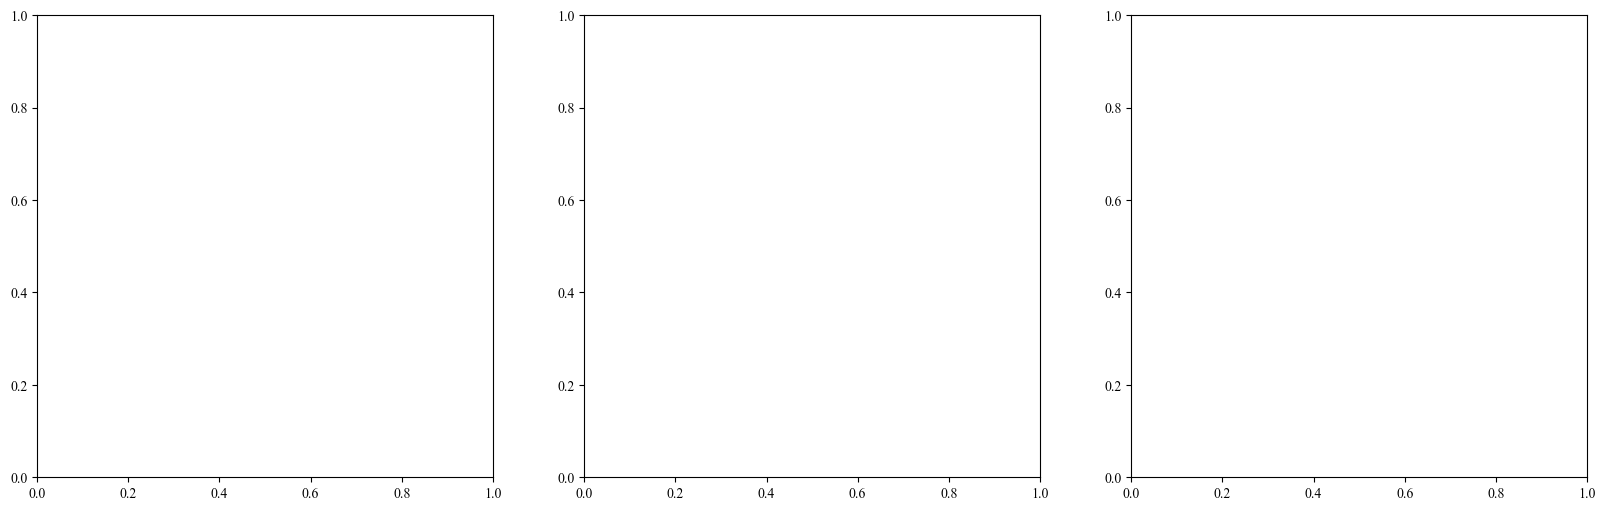

In [17]:
datetime_str = datetime.now().strftime("%Y%m%d_%H_h_%M_m")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_config_name = 'gin_3_new_5'

model = ModelFactory.create_model(
    model_config_name
)
train_config_name = 'default'
train_config = load_config("train", train_config_name)
optimizer_config_name = 'adam'
scheduler_config_name = 'step'

save_path = f"results/model_{model_config_name}_train_{train_config_name}_optim_{optimizer_config_name}_sch_{scheduler_config_name}/{datetime_str}"
os.makedirs(save_path, exist_ok=True)



trainer = Trainer(
    train_config=train_config,
    model=model,
    optimizer_config_name=optimizer_config_name,
    scheduler_config_name=scheduler_config_name,
    save_path=save_path,
    device=device,
)


trainer.fit(train_loader, valid_loader, epochs=EPOCHS, live_plot_step=10)
results = trainer.test(test_loader)

results = trainer.test(test_loader)

import json
with open(os.path.join(save_path, "results.json"), "w") as f:
    json.dump(results, f)
pd.DataFrame({'targets': results['targets'], 'predictions': results['predictions']}).to_csv(os.path.join(save_path, "predictions.csv"), index=False)


# Baseline Training

In [ ]:
import os
import sys
import torch
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader



project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.gnn.factory.model_factory import ModelFactory

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'


print("Loading dataset...")
train_data = torch.load(folder_path + '/train_datapyg_dataset.pt', weights_only=False, map_location=device)
valid_data = torch.load(folder_path + '/valid_datapyg_dataset.pt', weights_only=False, map_location=device)
test_data = torch.load(folder_path + '/test_datapyg_dataset.pt', weights_only=False, map_location=device)
test_loader = DataLoader(test_data, batch_size=15, shuffle=False)

print(f"Train 데이터 개수: {len(train_data)}")
print(f"Valid 데이터 개수: {len(valid_data)}")
print(f"Test 데이터 개수: {len(test_data)}")


In [ ]:
def extract_features(data_list):
    """
    From PyG Data objects, extract features and convert to tabular format
    """
    features = []
    targets = []

    for data in data_list:
        # x features (node features)
        x_features = data.x.cpu().numpy().flatten()  # ✅ .cpu() add

        # global_x features (global features)
        global_features = data.global_x.cpu().numpy().flatten()  # ✅ .cpu() add

        combined_features = np.concatenate([x_features, global_features])

        features.append(combined_features)
        targets.append(data.y.cpu().item())  # ✅ .cpu() add

    return np.array(features), np.array(targets)


print("Preprocessing data...")
X_train, y_train = extract_features(train_data)
X_valid, y_valid = extract_features(valid_data)
X_test, y_test = extract_features(test_data)

print(f"Feature shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"Feature names: x_stats + global_features")



In [ ]:
class BaselineModels:
    def __init__(self, need_y_scaling=False):
        self.models = {}
        self.scalers = {}
        self.y_scaler = {}
        self.need_y_scaling = need_y_scaling

    def y_scaling(self, y_train, y_valid):
        if self.need_y_scaling:
            y_scaler = StandardScaler()
            y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
            y_valid_scaled = y_scaler.transform(y_valid.reshape(-1, 1))
        else:
            y_scaler = None
            y_train_scaled = y_train
            y_valid_scaled = y_valid
        return y_scaler, y_train_scaled, y_valid_scaled

    def train_linear_regression(self, X_train, y_train, X_valid, y_valid):
        """Linear Regression"""
        print("Linear Regression...")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)

        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = LinearRegression()
        model.fit(X_train_scaled, y_train_scaled)

        self.models['linear_regression'] = model
        self.scalers['linear_regression'] = scaler
        self.y_scaler['linear_regression'] = y_scaler

        # evaluate
        y_pred = model.predict(X_valid_scaled)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)

        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, scaler, y_scaler


    def train_catboost(self, X_train, y_train, X_valid, y_valid):
        """CatBoost 모델"""
        print("CatBoost...")
        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = cb.CatBoostRegressor(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            random_seed=42,
            verbose=False
        )
        model.fit(X_train, y_train_scaled)

        self.models['catboost'] = model
        self.y_scaler['catboost'] = y_scaler

        # evaluate
        y_pred = model.predict(X_valid)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred.reshape(-1, 1)) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)

        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, None, y_scaler


    def evaluate_metrics(self, y_true, y_pred, prefix=''):
        # 1. MSE (Mean Squared Error)
        mse = mean_squared_error(y_true, y_pred)
        # 2. MAE (Mean Absolute Error)
        mae = mean_absolute_error(y_true, y_pred)
        # 3. RMSE (Root Mean Squared Error)
        rmse = np.sqrt(mse).item()
        # 4. R² (Coefficient of Determination)
        r2 = r2_score(y_true, y_pred)

        results = {
            f'{prefix}MSE': mse,
            f'{prefix}MAE': mae,
            f'{prefix}RMSE': rmse,
            f'{prefix}R²': r2,
        }
        return results


    def evaluate_all(self, X_test, y_test, save_path):
        import os
        os.makedirs(save_path, exist_ok=True)
        results = {}

        for name, model in self.models.items():
            if name == 'mlp':
                scaler = self.scalers[name]
                X_test_scaled = scaler.transform(X_test)
                X_test_tensor = torch.FloatTensor(X_test_scaled)

                model.eval()
                with torch.no_grad():
                    y_pred = model(X_test_tensor).numpy()
            elif name == 'linear_regression':
                scaler = self.scalers[name]
                X_test_scaled = scaler.transform(X_test)
                y_test_scaled = self.y_scaler[name].transform(y_test.reshape(-1, 1)) if self.y_scaler[name] else y_test
                y_pred = model.predict(X_test_scaled)
            else:
                y_test_scaled = self.y_scaler[name].transform(y_test.reshape(-1, 1)) if self.y_scaler[name] else y_test
                y_pred = model.predict(X_test)

            # origin scale
            y_pred_origin = self.y_scaler[name].inverse_transform(y_pred.reshape(-1, 1)) if self.y_scaler[name] else y_pred

            origin_metrics = self.evaluate_metrics(y_test, y_pred_origin, prefix='Origin_')
            scaled_metrics = self.evaluate_metrics(y_test_scaled, y_pred, prefix='Scaled_')

            all_metrics = {**origin_metrics, **scaled_metrics}
            results[name] = all_metrics

            print(f"""{name} -
            Origin_MSE: {all_metrics['Origin_MSE']:.4f}, Origin_MAE: {all_metrics['Origin_MAE']:.4f}, Origin_RMSE: {all_metrics['Origin_RMSE']:.4f}, Origin_R²: {all_metrics['Origin_R²']:.4f},
            Scaled_MSE: {all_metrics['Scaled_MSE']:.4f}, Scaled_MAE: {all_metrics['Scaled_MAE']:.4f}, Scaled_RMSE: {all_metrics['Scaled_RMSE']:.4f}, Scaled_R²: {all_metrics['Scaled_R²']:.4f}""")

            pd.DataFrame({'targets': y_test.tolist(), 'predictions': y_pred_origin.tolist()}).to_csv(os.path.join(save_path, f"scaled_{self.need_y_scaling}_{name}_predictions.csv"), index=False)

        return results


In [ ]:
def best_model_predict(model, loader, device):
    model.eval()
    model.to(device)
    y_pred = []
    y_true = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data).view(-1)
            y_pred.extend(out.cpu().numpy().tolist())
            y_true.extend(data.y.cpu().numpy().reshape(-1).tolist())

    return y_pred, y_true

In [ ]:
baseline_models = BaselineModels(need_y_scaling=False)
# 1. Linear Regression
baseline_models.train_linear_regression(X_train, y_train, X_valid, y_valid)

# 2. CatBoost
baseline_models.train_catboost(X_train, y_train, X_valid, y_valid)

print("=" * 50)
print("All models trained!")
print("=" * 50)


results = baseline_models.evaluate_all(X_test, y_test, save_path="baseline_results")


# 4. Best Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = ModelFactory.create_model(
    'gin_3_new_5'
)
best_model.load_state_dict(torch.load('output/gnn/field/best_model_gin.pt', map_location=device)) # add best model file path
best_model_predictions, best_model_targets = best_model_predict(best_model, test_loader, device)
best_model_scores = baseline_models.evaluate_metrics(best_model_targets, best_model_predictions, 'Origin_')
best_model_results = {'best_model': best_model_scores}
best_model_results = pd.DataFrame({'best_model': best_model_scores})

all_results = pd.DataFrame(results)
all_results = pd.concat([all_results, best_model_results], axis=1).T
all_results.head()


# Baseline - Visualization

In [ ]:
# Visualization Code
# 1. Visualization of Model Performance Comparison
plt.figure(figsize=(15, 10))

# R² Score Comparison
plt.subplot(2, 2, 1)
r2_scores = all_results['Origin_R²'].sort_values(ascending=True)
plt.barh(range(len(r2_scores)), r2_scores.values)
plt.yticks(range(len(r2_scores)), r2_scores.index)
plt.xlabel('R² Score')
plt.title('모델별 R² 성능 비교')
plt.grid(True, alpha=0.3)

# MSE Score Comparison
plt.subplot(2, 2, 2)
mse_scores = all_results['Origin_MSE'].sort_values(ascending=False)
plt.barh(range(len(mse_scores)), mse_scores.values)
plt.yticks(range(len(mse_scores)), mse_scores.index)
plt.xlabel('MSE')
plt.title('모델별 MSE 성능 비교')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# MAE Score Comparison
plt.subplot(2, 2, 1)
mae_scores = all_results['Origin_MAE'].sort_values(ascending=True)
plt.barh(range(len(mae_scores)), mae_scores.values)
plt.yticks(range(len(mae_scores)), mae_scores.index)
plt.xlabel('MAE')
plt.title('모델별 MAE 성능 비교')
plt.grid(True, alpha=0.3)


# 2. Visualization of Predicted vs. Actual Values (Best-performing Model)
plt.figure(figsize=(12, 5))


def predict(model_name, baseline_class, X):
    if model_name == 'linear_regression':
        scaler = baseline_class.scalers[model_name]
        X_scaled = scaler.transform(X)
    else:
        X_scaled = X_test
    model = baseline_class.models[model_name]
    y_pred = model.predict(X_scaled)

    if baseline_class.y_scaler[model_name] is not None:
        return baseline_class.y_scaler[model_name].inverse_transform(y_pred.reshape(-1, 1))
    else:
        return y_pred




model_names = ['linear_regression', 'catboost', 'best_model']

for model_name in model_names:
    if model_name == 'best_model':
        y_pred = best_model_predictions
        _y_test = np.array(best_model_targets)
    else:
        y_pred = predict(model_name, baseline_models, X_test).reshape(-1)
        _y_test = np.array(y_test)
    plt.subplot(1, 2, 1)
    plt.scatter(_y_test, y_pred, alpha=0.6)
    # plt.plot([_y_test.min(), _y_test.max()], [_y_test.min(), _y_test.max()], 'r--', lw=2)
    plt.plot([_y_test.min(), _y_test.max()], [_y_test.min(), _y_test.max()], 'r--', lw=2)
    plt.xlabel('실제 값')
    plt.ylabel('예측 값')
    plt.title(f'{model_name} - 예측 vs 실제 값')
    plt.grid(True, alpha=0.3)

    # Residual plot
    plt.subplot(1, 2, 2)
    residuals = _y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('예측 값')
    plt.ylabel('잔차')
    plt.title(f'{model_name} - 잔차 플롯')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()




# RL Learning

In [ ]:
from src.rl.src.train import main

main(config_path="src/rl/configs/default_low.yaml", run_name="run_1", device="auto")

  사용 장치: cuda

1. 데이터셋 로딩
Loaded PyG dataset: 8301 samples, 1849 modules per sample
Built 8300 episode pairs for interpolation
  초기 관측 (init_obs):
    - x.shape: torch.Size([1849, 4]) (노드 특징)
    - edge_index.shape: torch.Size([2, 5461])
    - global_x.shape: torch.Size([1, 7])
    - global_x 값: tensor([-6.8777e+01, -2.0230e+02,  4.5205e+02,  2.5882e-01, -9.6593e-01,
         6.1000e+01,  2.9400e+02])
    - y (target): 2955.751953125

2. 모듈-섹터 매핑 생성
  좌표 추출: (1849, 3)
  좌표 범위: X[-251.45, 251.45], Y[-156.36, 155.90], Z[-3.60, 100.73]
  클러스터링 파라미터: k_nn=3, tau=20.0
  클러스터링 결과: 64개 섹터
    - 비어있지 않은 섹터: 64/64 (100.0%)
    - 빈 섹터: 0개
    - 섹터별 모듈 수 (비어있지 않은 섹터만):
      min=14, max=55, mean=28.9, median=27.0
    - 섹터 크기 분포: 0-5:0, 5-10:0, 10-15:1, 15-20:7, 20-25:17, 25+:39

  B 행렬 통계:
    - Shape: (1849, 64) (모듈→섹터 매핑)
    - 밀도: 2.31%
    - 모듈당 연결된 섹터 수: min=1, max=3, mean=1.48
    - 경계 모듈: 794개 (42.9%)
    - 내부 모듈 (단일 섹터): 1055개

  섹터 간 연결:
    - M shape: (64, 64) (섹터 평활화)
    - A_sec 밀도: 8

In [ ]:
import glob, os, pprint

cands = glob.glob("src/rl/outputs/runs/*/checkpoint_final.pt")
if not cands:
    # Please note that the folder structure may vary slightly, so please perform a preliminary search as well
    cands = glob.glob("src/rl/outputs/runs/**/*.pt", recursive=True)

# Latest file as of the modification time
ckpt = max(cands, key=os.path.getmtime)
print("사용할 체크포인트:", ckpt)


In [ ]:
from pathlib import Path

path = Path("src/rl/runtime/controller.py")

text = path.read_text(encoding="utf-8")
text = (
    text.replace("✓", "[OK]")
        .replace("✗", "[X]")
        .replace("⚠️", "[WARN]")
        .replace("❌", "[ERROR]")
        .replace("🚀", "[START]")
)
path.write_text(text, encoding="utf-8")

print("모든 특수문자 교체 완료 ✅")



In [ ]:
from pathlib import Path

root = Path("src/rl/runtime")
replacements = {
    "\u2713": "[OK]",  # ✓
    "✓": "[OK]",
    "✗": "[X]",
    "⚠️": "[WARN]",
    "❌": "[ERROR]",
    "🚀": "[START]",
}

changed = []
for p in root.rglob("*.py"):
    txt = p.read_text(encoding="utf-8")
    new = txt
    for k, v in replacements.items():
        new = new.replace(k, v)
    if new != txt:
        p.write_text(new, encoding="utf-8")
        changed.append(str(p))

print("치환된 파일 수:", len(changed))
for c in changed:
    print(" -", c)


# Inference in a real-time environment

In [ ]:
#The Real-Time Environment of the Future
!python -m src.rl.runtime.runner --config src/rl/configs/runtime.yaml --once

In [3]:
#When adding a specific point in the past
import pandas as pd
import numpy as np
from pathlib import Path
import yaml

from src.rl.runtime.controller import RealTimeController

# Runtime configuration file
RUNTIME_CFG_PATH = "src/rl/configs/runtime.yaml"

# Create the controller once and reuse it
ctrl = RealTimeController(RUNTIME_CFG_PATH)


def export_theta_for_datetime(ts_str: str,
                              out_dir: str = "src/rl/outputs/sample_inference") -> Path:
    """
    특정 날짜·시간(ts_str, KST 기준)에 대한 모듈별 최종 각도 세트를 CSV로 저장.

    ts_str 예시: "2025-06-21 14:00"
    out_dir: CSV 저장 폴더
    """

    # 1) Create a Timestamp (KST)
    site_tz = ctrl.cfg["site"]["timezone"]   # runtime.yaml 의 site.timezone 사용
    ts_kst = pd.Timestamp(ts_str).tz_localize(site_tz)

    # 2) Since `run_once` uses `pd.Timestamp.now(...)` internally,
    #     Quickly monkey-patch it to trick it into using the “specified time”
    real_now = pd.Timestamp.now
    pd.Timestamp.now = lambda tz=None: ts_kst

    try:
        # This single line executes the entire control pipeline (GNN + RL + safety constraints)
        ctrl.run_once()
    finally:
        # Restore original function (make it available for real-time use again)
        pd.Timestamp.now = real_now

    # 3) After run_once() finishes, the final angle is stored in ctrl.cache.theta
    theta_final = ctrl.cache.theta  # shape = (N, )

    # 4) Retrieve the module ID and initial angle (theta_init) from modules.csv
    modules_csv_path = ctrl.cfg["artifacts"]["modules_csv_path"]
    modules_df = pd.read_csv(modules_csv_path)

    if "id" in modules_df.columns:
        module_ids = modules_df["id"].values
    else:
        module_ids = np.arange(len(theta_final))

    if "theta_init" in modules_df.columns:
        theta0_label = int(round(float(modules_df["theta_init"].mean())))
    else:
        theta0_label = 0

    # 5) Importing max_rate from runtime.yaml (include it in the filename)
    with open(RUNTIME_CFG_PATH, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    safety_cfg = cfg.get("safety", {})
    max_rate = float(safety_cfg.get("max_rate_deg_per_step", 5.0))

    # 6) Configuration of Save Path/Filename
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    ts_tag = ts_kst.strftime("%Y%m%d_%H%M")  # 예: 20250621_1400
    csv_name = f"sample_inference_result_theta_{theta0_label}_max_rate_{int(max_rate)}_{ts_tag}.csv"
    csv_path = out_dir / csv_name

    # 7) Save as CSV
    df_out = pd.DataFrame({
        "module_id": module_ids,
        "theta_pred_deg": theta_final.astype(float)
    })
    csv_path = df_out.to_csv(csv_path, index=False, encoding="utf-8")

    print(f"[OK] {ts_kst} 기준 각도 세트 CSV 저장 완료 → {csv_path}")
    return csv_path


[CONTROLLER] 사용 디바이스: cuda
  [BUS] ModbusBus 초기화: port=/dev/ttyUSB0, baudrate=115200, retries=2
[OK] 모듈 데이터 로드: 1849개 모듈
[OK] 그래프 구조 로드: 5461개 엣지
체크포인트 로드 중...
[OK] 매핑 행렬 로드: B(1849, 64), M(64, 64)
[OK] Bins: [-5. -3. -1.  0.  1.  3.  5.]
GNNPolicy 복원 중...
[OK] 정책 모델 로드 완료: S=64, B=7
[OK] 정책 모델 백본: C:\Users\HP\Downloads\GNNRL_v2\output\gnn\field\best_model_gin_with_class.pt
[OK] 정책 모델 체크포인트: src/rl/outputs/runs/20251106-194151/checkpoint_iter0840.pt


In [5]:
# Example 1: Summer Solstice (June 21) at 2:00 p.m.
export_theta_for_datetime("2025-06-21 10:00")





######################################################################
# 실시간 제어 사이클 시작
######################################################################
[CONTROLLER] 현재 시각 (KST): 2025-06-21 10:00:00+09:00
[CONTROLLER] 사이트 정보: lat=37.5, lon=127.0, alt=50m

[CONTROLLER] STEP 1/11: 태양 위치 계산
  [SOLAR] 태양 위치 계산 시작
  [SOLAR] 입력: ts=2025-06-21 10:00:00+09:00, lat=37.5, lon=127.0, alt=50m
  [SOLAR] [OK] pvlib 계산 완료: {'zenith': 35.68238880759624, 'azimuth': 102.0647360672811}
  [SOLAR] 구면 좌표: 고도=54.32°, 방위=102.06°, 천정각=35.68°
  [SOLAR] 데카르트 좌표: X=0.5704, Y=-0.1219, Z=0.8123
  [SOLAR] [OK] SunPosition 생성 완료
[CONTROLLER] [OK] 태양 위치 계산 완료

[CONTROLLER] STEP 2/11: 기상 데이터 조회

[WEATHER] 기상 데이터 조회 시작: 2025-06-21 10:00:00+09:00
[WEATHER] Provider: openweathermap_solar
[WEATHER] OpenWeatherMap Solar Irradiance API 호출...
  [OWM_SOLAR] Solar Irradiance API 호출 시작...
  [OWM_SOLAR] URL: https://api.openweathermap.org/energy/2.0/solar/interval_data
  [OWM_SOLAR] Params: lat=37.5, lon=127.0, date=2025-06

In [ ]:
######################################################################
#10. Explain how the data was split for training and testing, and add the errors results for both training, validation and testing dataset. 




In [9]:
import torch
import numpy as np
import pandas as pd
from torch_geometric.loader import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

# 1. 환경 설정 및 장치 지정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
folder_path = "./src/gnn/data" #
model_path = 'output/gnn/field/best_model_gin.pt' 

# 2. 데이터셋 로드 (weights_only=False 옵션 추가)
print("Loading datasets...")
# PyTorch 2.6+ 대응을 위해 weights_only=False를 명시합니다.
train_dataset = torch.load(folder_path + '/train_datapyg_dataset.pt', map_location=device, weights_only=False)
valid_dataset = torch.load(folder_path + '/valid_datapyg_dataset.pt', map_location=device, weights_only=False)
test_dataset = torch.load(folder_path + '/test_datapyg_dataset.pt', map_location=device, weights_only=False)

# 3. 데이터 로더 설정 (셔플하지 않음)
batch_size = 16 #
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 4. 모델 로드 (ModelFactory 사용)
from src.gnn.factory.model_factory import ModelFactory
model = ModelFactory.create_model('gin_3_new_5') #
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# 5. 평가 함수 정의
def evaluate_set(loader, model, device):
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            output = model(data)
            all_preds.append(output.view(-1).cpu().numpy())
            all_targets.append(data.y.view(-1).cpu().numpy())
            
    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)
    
    mse = mean_squared_error(targets, preds)
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(targets, preds)
    
    return len(targets), mse, mae, rmse, r2

# 6. 각 데이터셋 별 메트릭 계산
print("Calculating metrics for each split...")
sets = [
    ("Training", train_loader),
    ("Validation", valid_loader),
    ("Testing", test_loader)
]

results_list = []
for name, loader in sets:
    n_samples, mse, mae, rmse, r2 = evaluate_set(loader, model, device)
    results_list.append({
        "Dataset": name,
        "Sample Size (N)": n_samples,
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

# 7. 결과 출력 (Table X)
df_results = pd.DataFrame(results_list)
print("\nTable X. Performance Error Metrics (Split Ratio: 70:15:15)")
print("=" * 80)
print(df_results.to_string(index=False))
print("=" * 80)

Loading datasets...
Calculating metrics for each split...

Table X. Performance Error Metrics (Split Ratio: 70:15:15)
   Dataset  Sample Size (N)        MSE      MAE     RMSE  R2 Score
  Training             6458 60011.8984 135.4781 244.9733    0.9847
Validation             1387 61367.1992 138.0061 247.7240    0.9838
   Testing             1384 47117.0586 127.3218 217.0646    0.9878


In [23]:
import glob
import os
import torch
import pandas as pd
import numpy as np
from torch_geometric.loader import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 경로 설정 (노트북의 Cell 9, 10 설정을 그대로 가져옴)
folder_path = "./src/gnn/data"
EPW_FILE_PATH = "./src/gnn/EPW_Mar-Nov_SolarData_WithTemp_v2.csv"
model_path = 'output/gnn/field/best_model_gin.pt'

# 2. 22,170개 원시 CSV 파일 리스트 찾기
node_csv_files = glob.glob(os.path.join(folder_path, "**", "*node*.csv"), recursive=True)
edge_csv_files = glob.glob(os.path.join(folder_path, "**", "*edge*.csv"), recursive=True)
node_csv_files.sort()
edge_csv_files.sort()

print(f"찾은 전체 노드 파일 수: {len(node_csv_files)}")

# 3. 데이터셋 생성 함수 (노트북 Cell 12의 로직 활용)
import src.gnn.utils.pyg_dataset as pyg_dataset

# 전체 데이터를 대상으로 데이터셋 생성 (Fail 파일은 자동으로 제외됨)
full_dataset, fail_files, _ = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=node_csv_files,
    edge_file_paths=edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=2,  # START_NODE_ID
    end_node_id=1850, # END_NODE_ID
    sun_node_id=0,    # SUN_NODE_ID
    pitch_node_id=1,  # PITCH_NODE_ID
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True
)

# 4. 모델 로드 및 평가
from src.gnn.factory.model_factory import ModelFactory
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ModelFactory.create_model('gin_3_new_5')
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device).eval()

loader = DataLoader(full_dataset, batch_size=16, shuffle=False)

all_preds, all_targets = [], []
with torch.no_grad():
    for data in loader:
        data = data.to(device)
        output = model(data)
        all_preds.append(output.view(-1).cpu().numpy())
        all_targets.append(data.y.view(-1).cpu().numpy())

preds = np.concatenate(all_preds)
targets = np.concatenate(all_targets)

# 5. 최종 결과 출력
print("\n" + "="*50)
print(f"전체 원시 데이터 평가 결과 (총 {len(node_csv_files)}건 중 유효 데이터 {len(targets)}건)")
print("-" * 50)
print(f"MSE  : {mean_squared_error(targets, preds):.4f}")
print(f"MAE  : {mean_absolute_error(targets, preds):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(targets, preds)):.4f}")
print(f"R2   : {r2_score(targets, preds):.4f}")
print("="*50)

찾은 전체 노드 파일 수: 9379


ModuleNotFoundError: No module named 'utils'